# NLP Pipeline — Phase 1
### Image OCR → Text Cleaning → Tokenisation → Stopwords → Lemmatisation → NER → Key Phrases → Dependency Parsing
---

## Imports

In [1]:
# ── Image / OCR ───────────────────────────────────────────────────────────
import cv2
import pytesseract

# ── Core NLP ──────────────────────────────────────────────────────────────
import spacy
from spacy import displacy
from IPython.display import display, HTML

# ── NLTK ──────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords',  quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('wordnet',    quiet=True)

# ── Utilities ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

print('All libraries loaded successfully.')

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


All libraries loaded successfully.


---
## Image Input with OCR 

Image loaded successfully.
Shape (height, width, channels): (1993, 1135, 3)


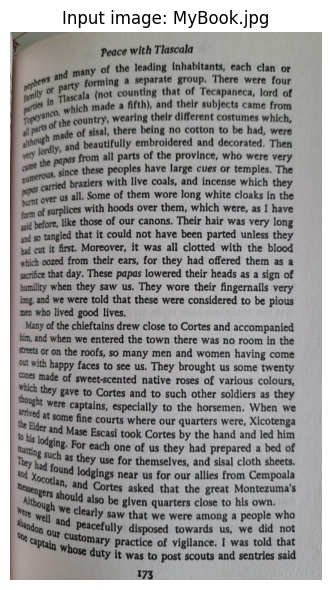

In [2]:
# ── Load image with OpenCV ────────────────────────────────────────────────
# Change 'MyBook.jpg' to your own image file name.
# The file must be in the same folder as this notebook.
IMAGE_FILE = 'MyBook.jpg'

img = cv2.imread(IMAGE_FILE)

if img is None:
    raise FileNotFoundError(
        f"Could not load '{IMAGE_FILE}'. "
        "Make sure the image is in the same directory as this notebook."
    )

print('Image loaded successfully.')
print(f'Shape (height, width, channels): {img.shape}')

# ── Display the image inline ──────────────────────────────────────────────
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f'Input image: {IMAGE_FILE}', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# ── OCR with Tesseract ────────────────────────────────────────────────────
# --oem 1  = LSTM neural network engine (Tesseract 5)
# --psm 6  = assume a uniform block of text
custom_config = r'--oem 1 --psm 6'

ocr_text = pytesseract.image_to_string(img, config=custom_config)

print('=== RAW OCR OUTPUT ===')
print(ocr_text)

=== RAW OCR OUTPUT ===
Peace with Tlascala
\ and many of the leading inhabit.
F pepheS arty forming 4 separate grou ants, each clan or
ies in Tiascala (not counting that of Tecapanec mp
p yanco, which made a fifth), and their subjects a, lord of
wrt of the country, wearing their different co came from
‘ough made of sisal, there being no cotton ta ta which,
a jordly, and beautifully embroidered and d had, were
wipe the papas from all parts of the ecorated. Then
province, who w
merous, since these peoples have | pepsthiee
0 arge cues or templ
pans carried braziers with live coals, and incense + regi
purnt over US all. Some of them wore long white oad they
form of surplices with hoods over them, whi s in the
wid before, like those of our canons. Their eine as I have
“ vowing it could not have been porn very long
eseoesd ee ee oh clotted hnllperinetn
from their ears, for they had the blood
seriice that day. These papas | y had offered them as a
pas lowered th
humility when they saw us. Th 

---
## 1 Tokenisation
### 1a NLTK Tokenisation

In [4]:
# ── Tokenise the OCR text using NLTK word_tokenize ────────────────────────
text_tokens = word_tokenize(ocr_text)

print('=== NLTK TOKENS ===')
print(text_tokens)
print(f'\nTotal tokens: {len(text_tokens)}')

=== NLTK TOKENS ===
['Peace', 'with', 'Tlascala', '\\', 'and', 'many', 'of', 'the', 'leading', 'inhabit', '.', 'F', 'pepheS', 'arty', 'forming', '4', 'separate', 'grou', 'ants', ',', 'each', 'clan', 'or', 'ies', 'in', 'Tiascala', '(', 'not', 'counting', 'that', 'of', 'Tecapanec', 'mp', 'p', 'yanco', ',', 'which', 'made', 'a', 'fifth', ')', ',', 'and', 'their', 'subjects', 'a', ',', 'lord', 'of', 'wrt', 'of', 'the', 'country', ',', 'wearing', 'their', 'different', 'co', 'came', 'from', '‘', 'ough', 'made', 'of', 'sisal', ',', 'there', 'being', 'no', 'cotton', 'ta', 'ta', 'which', ',', 'a', 'jordly', ',', 'and', 'beautifully', 'embroidered', 'and', 'd', 'had', ',', 'were', 'wipe', 'the', 'papas', 'from', 'all', 'parts', 'of', 'the', 'ecorated', '.', 'Then', 'province', ',', 'who', 'w', 'merous', ',', 'since', 'these', 'peoples', 'have', '|', 'pepsthiee', '0', 'arge', 'cues', 'or', 'templ', 'pans', 'carried', 'braziers', 'with', 'live', 'coals', ',', 'and', 'incense', '+', 'regi', 'purnt'

### 1b. spaCy Tokenisation

In [5]:
# ── Tokenise with spaCy ───────────────────────────────────────────────────
doc = nlp(ocr_text)

print('=== spaCy TOKENS ===')
for token in doc:
    print(token.text, token.pos_, end=' | ')

print(f'\n\nTotal tokens: {len(doc)}')
print(f'Vocabulary size (en_core_web_sm): {len(doc.vocab)}')

=== spaCy TOKENS ===
Peace NOUN | with ADP | Tlascala PROPN | 
 SPACE | \ PROPN | and CCONJ | many ADJ | of ADP | the DET | leading VERB | inhabit NOUN | . PUNCT | 
 SPACE | F PROPN | pepheS PROPN | arty NOUN | forming VERB | 4 NUM | separate ADJ | grou NOUN | ants NOUN | , PUNCT | each DET | clan NOUN | or CCONJ | 
 SPACE | ies ADV | in ADP | Tiascala PROPN | ( PUNCT | not PART | counting VERB | that PRON | of ADP | Tecapanec PROPN | mp NOUN | 
 SPACE | p NOUN | yanco NOUN | , PUNCT | which PRON | made VERB | a DET | fifth ADJ | ) PUNCT | , PUNCT | and CCONJ | their PRON | subjects NOUN | a PRON | , PUNCT | lord PROPN | of ADP | 
 SPACE | wrt NOUN | of ADP | the DET | country NOUN | , PUNCT | wearing VERB | their PRON | different ADJ | co NOUN | came VERB | from ADP | 
 SPACE | ‘ PUNCT | ough ADV | made VERB | of ADP | sisal NOUN | , PUNCT | there PRON | being AUX | no DET | cotton NOUN | ta ADP | ta PROPN | which PRON | , PUNCT | 
 SPACE | a DET | jordly ADV | , PUNCT | and CCONJ | b

### 1c. Tokenisation edge cases

In [6]:
# ── Demonstrate tokenisation on tricky text ───────────────────────────────
# Escaped quotes, abbreviations, apostrophes
sentence = '"Mr. O\'Neill thinks that the boys\' stories about Chile\'s capital aren\'t amusing."'
print('Sentence:', sentence)
print()

nlp_sentence = nlp(sentence)
for token in nlp_sentence:
    print(token.text, token.pos_, end=' | ')

print()
print()

# URLs and times
sentence2 = 'It is best to access our website from 9 a.m. to 1 p.m. every weekend. The address is www.mywebsite.ie.'
doc2 = nlp(sentence2)
print('Sentence:', sentence2)
for token in doc2:
    print(token, end=' | ')

Sentence: "Mr. O'Neill thinks that the boys' stories about Chile's capital aren't amusing."

" PUNCT | Mr. PROPN | O'Neill PROPN | thinks VERB | that SCONJ | the DET | boys NOUN | ' PART | stories NOUN | about ADP | Chile PROPN | 's PART | capital NOUN | are AUX | n't PART | amusing ADJ | . PUNCT | " PUNCT | 

Sentence: It is best to access our website from 9 a.m. to 1 p.m. every weekend. The address is www.mywebsite.ie.
It | is | best | to | access | our | website | from | 9 | a.m. | to | 1 | p.m. | every | weekend | . | The | address | is | www.mywebsite.ie | . | 

### 1d. Slicing tokens

In [7]:
# ── Token slicing ─────────────────────────────────────────────────────────
demo = nlp(u'I really like working with words!')

print('All tokens:')
for token in demo:
    print(token)

print('\nFirst token :', demo[0])
print('Last 2 tokens:', demo[-2:])

All tokens:
I
really
like
working
with
words
!

First token : I
Last 2 tokens: words!


---
## 2. Stopword Removal
### 2a. NLTK stopwords

In [8]:
# ── NLTK stopword removal on OCR text ────────────────────────────────────
nltk_stopwords = stopwords.words('english')

tokens_without_sw = [word for word in text_tokens if word not in nltk_stopwords]

print('=== AFTER NLTK STOPWORD REMOVAL ===')
print(tokens_without_sw)
print(f'\nOriginal token count : {len(text_tokens)}')
print(f'After filtering      : {len(tokens_without_sw)}')
print(f'Stopwords removed    : {len(text_tokens) - len(tokens_without_sw)}')
print(f'\nNLTK stopword list size: {len(nltk_stopwords)}')
print(nltk_stopwords)

=== AFTER NLTK STOPWORD REMOVAL ===
['Peace', 'Tlascala', '\\', 'many', 'leading', 'inhabit', '.', 'F', 'pepheS', 'arty', 'forming', '4', 'separate', 'grou', 'ants', ',', 'clan', 'ies', 'Tiascala', '(', 'counting', 'Tecapanec', 'mp', 'p', 'yanco', ',', 'made', 'fifth', ')', ',', 'subjects', ',', 'lord', 'wrt', 'country', ',', 'wearing', 'different', 'co', 'came', '‘', 'ough', 'made', 'sisal', ',', 'cotton', 'ta', 'ta', ',', 'jordly', ',', 'beautifully', 'embroidered', ',', 'wipe', 'papas', 'parts', 'ecorated', '.', 'Then', 'province', ',', 'w', 'merous', ',', 'since', 'peoples', '|', 'pepsthiee', '0', 'arge', 'cues', 'templ', 'pans', 'carried', 'braziers', 'live', 'coals', ',', 'incense', '+', 'regi', 'purnt', 'US', '.', 'Some', 'wore', 'long', 'white', 'oad', 'form', 'surplices', 'hoods', ',', 'whi', 'wid', ',', 'like', 'canons', '.', 'Their', 'eine', 'I', '“', 'vowing', 'could', 'porn', 'long', 'eseoesd', 'ee', 'ee', 'oh', 'clotted', 'hnllperinetn', 'ears', ',', 'blood', 'seriice', '

### 2b. Appending and extending the stopword list

In [9]:
# ── Add a single custom stopword ──────────────────────────────────────────
all_stopwords = stopwords.words('english')
all_stopwords.append('Lorem')

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('After appending "Lorem":')
print(tokens_without_sw)
print(f'Stopword count: {len(all_stopwords)}')

# ── Extend with a list of custom stopwords ────────────────────────────────
sw_list = ['Ipsum', 'dummy', '2000', 'simply']
all_stopwords.extend(sw_list)

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('\nAfter extending with list:')
print(tokens_without_sw)
print(f'Stopword count: {len(all_stopwords)}')

After appending "Lorem":
['Peace', 'Tlascala', '\\', 'many', 'leading', 'inhabit', '.', 'F', 'pepheS', 'arty', 'forming', '4', 'separate', 'grou', 'ants', ',', 'clan', 'ies', 'Tiascala', '(', 'counting', 'Tecapanec', 'mp', 'p', 'yanco', ',', 'made', 'fifth', ')', ',', 'subjects', ',', 'lord', 'wrt', 'country', ',', 'wearing', 'different', 'co', 'came', '‘', 'ough', 'made', 'sisal', ',', 'cotton', 'ta', 'ta', ',', 'jordly', ',', 'beautifully', 'embroidered', ',', 'wipe', 'papas', 'parts', 'ecorated', '.', 'Then', 'province', ',', 'w', 'merous', ',', 'since', 'peoples', '|', 'pepsthiee', '0', 'arge', 'cues', 'templ', 'pans', 'carried', 'braziers', 'live', 'coals', ',', 'incense', '+', 'regi', 'purnt', 'US', '.', 'Some', 'wore', 'long', 'white', 'oad', 'form', 'surplices', 'hoods', ',', 'whi', 'wid', ',', 'like', 'canons', '.', 'Their', 'eine', 'I', '“', 'vowing', 'could', 'porn', 'long', 'eseoesd', 'ee', 'ee', 'oh', 'clotted', 'hnllperinetn', 'ears', ',', 'blood', 'seriice', 'day', '.', 

### 2c. Removing a stopword

In [10]:
# ── Remove 'not' so negation is preserved ────────────────────────────────
all_stopwords = stopwords.words('english')
all_stopwords.remove('not')

tokens_without_sw = [word for word in text_tokens if word not in all_stopwords]
print('After removing "not" from stopwords:')
print(tokens_without_sw)

After removing "not" from stopwords:
['Peace', 'Tlascala', '\\', 'many', 'leading', 'inhabit', '.', 'F', 'pepheS', 'arty', 'forming', '4', 'separate', 'grou', 'ants', ',', 'clan', 'ies', 'Tiascala', '(', 'not', 'counting', 'Tecapanec', 'mp', 'p', 'yanco', ',', 'made', 'fifth', ')', ',', 'subjects', ',', 'lord', 'wrt', 'country', ',', 'wearing', 'different', 'co', 'came', '‘', 'ough', 'made', 'sisal', ',', 'cotton', 'ta', 'ta', ',', 'jordly', ',', 'beautifully', 'embroidered', ',', 'wipe', 'papas', 'parts', 'ecorated', '.', 'Then', 'province', ',', 'w', 'merous', ',', 'since', 'peoples', '|', 'pepsthiee', '0', 'arge', 'cues', 'templ', 'pans', 'carried', 'braziers', 'live', 'coals', ',', 'incense', '+', 'regi', 'purnt', 'US', '.', 'Some', 'wore', 'long', 'white', 'oad', 'form', 'surplices', 'hoods', ',', 'whi', 'wid', ',', 'like', 'canons', '.', 'Their', 'eine', 'I', '“', 'vowing', 'could', 'not', 'porn', 'long', 'eseoesd', 'ee', 'ee', 'oh', 'clotted', 'hnllperinetn', 'ears', ',', 'blood

### 2d. spaCy stopword removal

In [11]:
# ── spaCy stopword list ───────────────────────────────────────────────────
sp_stopwords = nlp.Defaults.stop_words

text_kevin = 'Kevin likes to write code in Java, however he is not too fond of C++.'
kevin_tokens = word_tokenize(text_kevin)

tokens_without_sw = [word for word in kevin_tokens if word not in sp_stopwords]
print('spaCy — stopwords removed:')
print(tokens_without_sw)
print(f'\nspaCy stopword list size: {len(sp_stopwords)}')

# ── Add a custom token to spaCy stopwords ────────────────────────────────
sp_stopwords.add('C++')
tokens_without_sw = [word for word in kevin_tokens if word not in sp_stopwords]
print('\nAfter adding "C++" to spaCy stopwords:')
print(tokens_without_sw)

# ── Remove 'not' from spaCy stopwords ────────────────────────────────────
sp_stopwords = nlp.Defaults.stop_words
sp_stopwords.remove('not')
tokens_without_sw = [word for word in kevin_tokens if word not in sp_stopwords]
print('\nAfter removing "not" from spaCy stopwords:')
print(tokens_without_sw)

spaCy — stopwords removed:
['Kevin', 'likes', 'write', 'code', 'Java', ',', 'fond', 'C++', '.']

spaCy stopword list size: 326

After adding "C++" to spaCy stopwords:
['Kevin', 'likes', 'write', 'code', 'Java', ',', 'fond', '.']

After removing "not" from spaCy stopwords:
['Kevin', 'likes', 'write', 'code', 'Java', ',', 'not', 'fond', '.']


### 2e. spaCy stopword removal from OCR text

In [12]:
# ── Apply spaCy stopword removal to OCR text ──────────────────────────────
doc = nlp(ocr_text)

filtered_tokens = [
    token.text
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
]
clean_text = ' '.join(filtered_tokens)

print('=== CLEANED TEXT (spaCy — stopwords + punctuation removed) ===')
print(clean_text)

total_count    = len([t for t in doc if not t.is_punct and not t.is_space])
filtered_count = len(filtered_tokens)
stopword_count = total_count - filtered_count

print(f'\nTotal tokens (with stopwords) : {total_count}')
print(f'Tokens (without stopwords)    : {filtered_count}')
print(f'Stopwords removed             : {stopword_count}')

=== CLEANED TEXT (spaCy — stopwords + punctuation removed) ===
Peace Tlascala leading inhabit F pepheS arty forming 4 separate grou ants clan ies Tiascala counting Tecapanec mp p yanco fifth subjects lord wrt country wearing different co came ough sisal cotton ta ta jordly beautifully embroidered d wipe papas parts ecorated province w merous peoples | pepsthiee 0 arge cues templ pans carried braziers live coals incense + regi purnt wore long white oad form surplices hoods whi s wid like canons eine vowing porn long eseoesd ee ee oh clotted hnllperinetn ears blood seriice day papas | y offered pas lowered th humility saw Th cir heads sign long told th ey wore fingernails men lived good lives ese considered pious chieftai ee jean accompanied roofs ma ere room happy faces ny men women having co cones b g come sweet scented nati y brought ie gave Cortes ve roses colour captains es lov soldiers te rr fine hie horsemen 1 | Mase Escasi quarters Xicoten ma Odging took Cortes hand ming th led y

---
## 3. Lemmatisation
### 3a. spaCy lemmatisation (context-aware)

In [13]:
# ── Lemmatise using spaCy ─────────────────────────────────────────────────
doc = nlp(ocr_text)

lemmatised = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
]

print('=== LEMMATISED TOKENS ===')
print(' | '.join(lemmatised))

=== LEMMATISED TOKENS ===
peace | tlascala | lead | inhabit | f | pephes | arty | form | 4 | separate | grou | ant | clan | ies | tiascala | count | tecapanec | mp | p | yanco | fifth | subject | lord | wrt | country | wear | different | co | come | ough | sisal | cotton | ta | ta | jordly | beautifully | embroider | d | wipe | papa | part | ecorate | province | w | merous | people | | | pepsthiee | 0 | arge | cue | templ | pan | carry | brazier | live | coal | incense | + | regi | purnt | wear | long | white | oad | form | surplice | hood | whi | s | wid | like | canon | eine | vow | porn | long | eseoesd | ee | ee | oh | clot | hnllperinetn | ear | blood | seriice | day | papa | | | y | offer | pas | lower | th | humility | see | th | cir | head | sign | long | tell | th | ey | wear | fingernail | man | live | good | life | ese | consider | pious | chieftai | ee | jean | accompany | roof | ma | ere | room | happy | face | ny | man | woman | having | co | cone | b | g | come | sweet |

### 3b. Filtered vs lemmatised — side-by-side

In [14]:
# ── Compare filtered tokens vs their lemmas ───────────────────────────────
filtered = [
    token.text.lower()
    for token in doc
    if not token.is_stop and not token.is_punct and not token.is_space
]

print(f'{"Original":<25} {"Lemmatised (spaCy)":<25}')
print('-' * 50)
for orig, lemma in zip(filtered, lemmatised):
    print(f'{orig:<25} {lemma:<25}')

Original                  Lemmatised (spaCy)       
--------------------------------------------------
peace                     peace                    
tlascala                  tlascala                 
leading                   lead                     
inhabit                   inhabit                  
f                         f                        
pephes                    pephes                   
arty                      arty                     
forming                   form                     
4                         4                        
separate                  separate                 
grou                      grou                     
ants                      ant                      
clan                      clan                     
ies                       ies                      
tiascala                  tiascala                 
counting                  count                    
tecapanec                 tecapanec                
mp           

---
## 4. Named Entity Recognition (NER)
### 4a. Entity extraction using spaCy

In [15]:
# ── NER on a sample sentence ──────────────────────────────────────────────
doc_object = nlp(u'Samsung in Ireland are pleased with their new folding screen '
                 u'that they released after a large $9 million investment.')

# Basic entity print
print('=== ENTITIES ===')
for entity in doc_object.ents:
    print(entity)

print()

# Entity + label
print('=== ENTITY + LABEL ===')
for entity in doc_object.ents:
    print(entity, entity.label_)

print()

# Entity + label + description
print('=== ENTITY + LABEL + DESCRIPTION ===')
for entity in doc_object.ents:
    print(entity, entity.label_, spacy.explain(entity.label_))

=== ENTITIES ===
Samsung
Ireland
a large
$9 million

=== ENTITY + LABEL ===
Samsung ORG
Ireland GPE
a large MONEY
$9 million MONEY

=== ENTITY + LABEL + DESCRIPTION ===
Samsung ORG Companies, agencies, institutions, etc.
Ireland GPE Countries, cities, states
a large MONEY Monetary values, including unit
$9 million MONEY Monetary values, including unit


In [16]:
# ── show_entity_info helper function ─────────────────────────────────────
def show_entity_info(doc_object):
    """Print entity text, label and description in a table."""
    if doc_object.ents:
        header = f'{"Entity":<30} {"Label":<20} {"Description"}'
        print(header)
        print('-' * 70)
        for entity in doc_object.ents:
            print(f'{entity.text:<30} {entity.label_:<20} {spacy.explain(entity.label_)}')
    else:
        print('No entities found in text.')

# ── Apply to the OCR text ─────────────────────────────────────────────────
print('=== NER — OCR TEXT ===')
show_entity_info(nlp(ocr_text))

=== NER — OCR TEXT ===
Entity                         Label                Description
----------------------------------------------------------------------
Tlascala                       GPE                  Countries, cities, states
\                              PERSON               People, including fictional
F pepheS                       PRODUCT              Objects, vehicles, foods, etc. (not services)
4                              CARDINAL             Numerals that do not fall under another type
Tiascala                       GPE                  Countries, cities, states
Tecapanec                      PERSON               People, including fictional
fifth                          ORDINAL              "first", "second", etc.
0                              CARDINAL             Numerals that do not fall under another type
+ regi                         PERSON               People, including fictional
US                             GPE                  Countries, cities, states


### 4b. NER visualisation with displaCy

In [17]:
# ── Render NER with displaCy ──────────────────────────────────────────────
doc_object = nlp(ocr_text)

html = displacy.render(doc_object, style='ent', jupyter=False)
display(HTML(html))

---
## 5. Key Phrases — Noun Chunks
### 5a. Extracting noun chunks

In [18]:
# ── Noun chunk extraction ─────────────────────────────────────────────────
doc_object = nlp(u'Autonomous cars shift insurance liability toward manufacturers')

column1 = 'Text'
column2 = 'Root text'
column3 = 'Root dependency'
column4 = 'Root head text'

print(f'{column1:25} {column2:20} {column3:25} {column4:20}')

for chunk in doc_object.noun_chunks:
    print(f'{chunk.text:{25}} {chunk.root.text:{20}} '
          f'{spacy.explain(chunk.root.dep_):{25}} {chunk.root.head.text:{20}}')

Text                      Root text            Root dependency           Root head text      
Autonomous cars           cars                 nominal subject           shift               
insurance liability       liability            direct object             shift               
manufacturers             manufacturers        object of preposition     toward              


### 5b. Noun chunks from OCR text

In [19]:
# ── Key phrases from the OCR document ────────────────────────────────────
doc_ocr = nlp(ocr_text)

print(f'{"Phrase":<35} {"Root":<18} {"Dependency":<28} {"Head"}')
print('-' * 90)

for chunk in doc_ocr.noun_chunks:
    print(f'{chunk.text:<35} {chunk.root.text:<18} '
          f'{str(spacy.explain(chunk.root.dep_)):<28} {chunk.root.head.text}')

Phrase                              Root               Dependency                   Head
------------------------------------------------------------------------------------------
Peace                               Peace              root                         Peace
Tlascala
\                          \                  object of preposition        with
the leading inhabit                 inhabit            object of preposition        of
F pepheS arty                       arty               nominal subject              forming
4 separate grou ants                ants               direct object                forming
each clan                           clan               appositional modifier        ants
Tiascala                            Tiascala           object of preposition        in
that                                that               direct object                counting
Tecapanec                           Tecapanec          object of preposition        of
mp
p yanco    

---
## 6. Dependency Parsing with displaCy

In [20]:
# ── Dependency parse — longer passage ────────────────────────────────────
doc_object = nlp(u"""It is natural and right you should all go to homes of your own in time,
but I do want to keep my girls as long as I can, and I am sorry that this happened so soon,
for Meg is only seventeen and it will be some years before John can make a home for her""")

html = displacy.render(
    doc_object,
    style='dep',
    jupyter=False,
    options={
        'distance'     : 130,
        'color'        : 'blue',
        'arrow_stroke' : 4,
        'arrow_spacing': 20,
        'word_spacing' : 50,
        'compact'      : True
    }
)

display(HTML(html))

In [21]:
# ── Named entities in the same passage ───────────────────────────────────
print('=== ENTITIES IN PASSAGE ===')
for entity in doc_object.ents:
    print(entity, entity.label_)

=== ENTITIES IN PASSAGE ===
Meg ORG
only seventeen CARDINAL
some years DATE
John PERSON


In [22]:
# ── Dependency parse — shorter technical sentence ─────────────────────────
parse_sentence = 'Researchers at Google and OpenAI have published papers on named entity recognition.'
doc_parse = nlp(parse_sentence)

html = displacy.render(
    doc_parse,
    style='dep',
    jupyter=False,
    options={
        'distance'     : 120,
        'color'        : 'blue',
        'arrow_stroke' : 3,
        'arrow_spacing': 20,
        'word_spacing' : 45,
        'compact'      : True
    }
)

display(HTML(html))